# HW3: Animal Image Classification — CNN from Scratch vs. Transfer Learning

In this notebook we tackle a 10-class animal image classification task using three progressively more powerful approaches:

1. **CNN trained from scratch** — a custom convolutional neural network with no pre-trained knowledge.
2. **Frozen transfer learning** — a pre-trained ResNet-50 used as a fixed feature extractor, with only the final classification layer trained.
3. **Fine-tuned transfer learning** — the same ResNet-50, but with the last convolutional block (`layer4[2]`) and the classifier unfrozen so the model can adapt its learned features to our dataset.

The goal is to compare these strategies and understand how transfer learning improves performance on a relatively small dataset.

## 1. Imports and Configuration

We load all required libraries up front: PyTorch for model building and training, torchvision for pre-trained models and image transforms, scikit-learn for clustering/PCA utilities, and UMAP for dimensionality reduction. A fixed random seed (`1090`) is used throughout for reproducibility.

In [ ]:
import os
import gc
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights

import umap
from tqdm import tqdm

warnings.filterwarnings('ignore')

KMEANS_N_INIT = 100

from pathlib import Path
DATA_ROOT = Path('163602/datasets')


## 2. Dataset Exploration

The dataset is organized into `train/`, `val/`, and `test/` splits, each containing subdirectories for the 10 animal classes. Below we visualize 7 randomly sampled training images per class and print the class distribution to confirm the dataset is reasonably balanced.

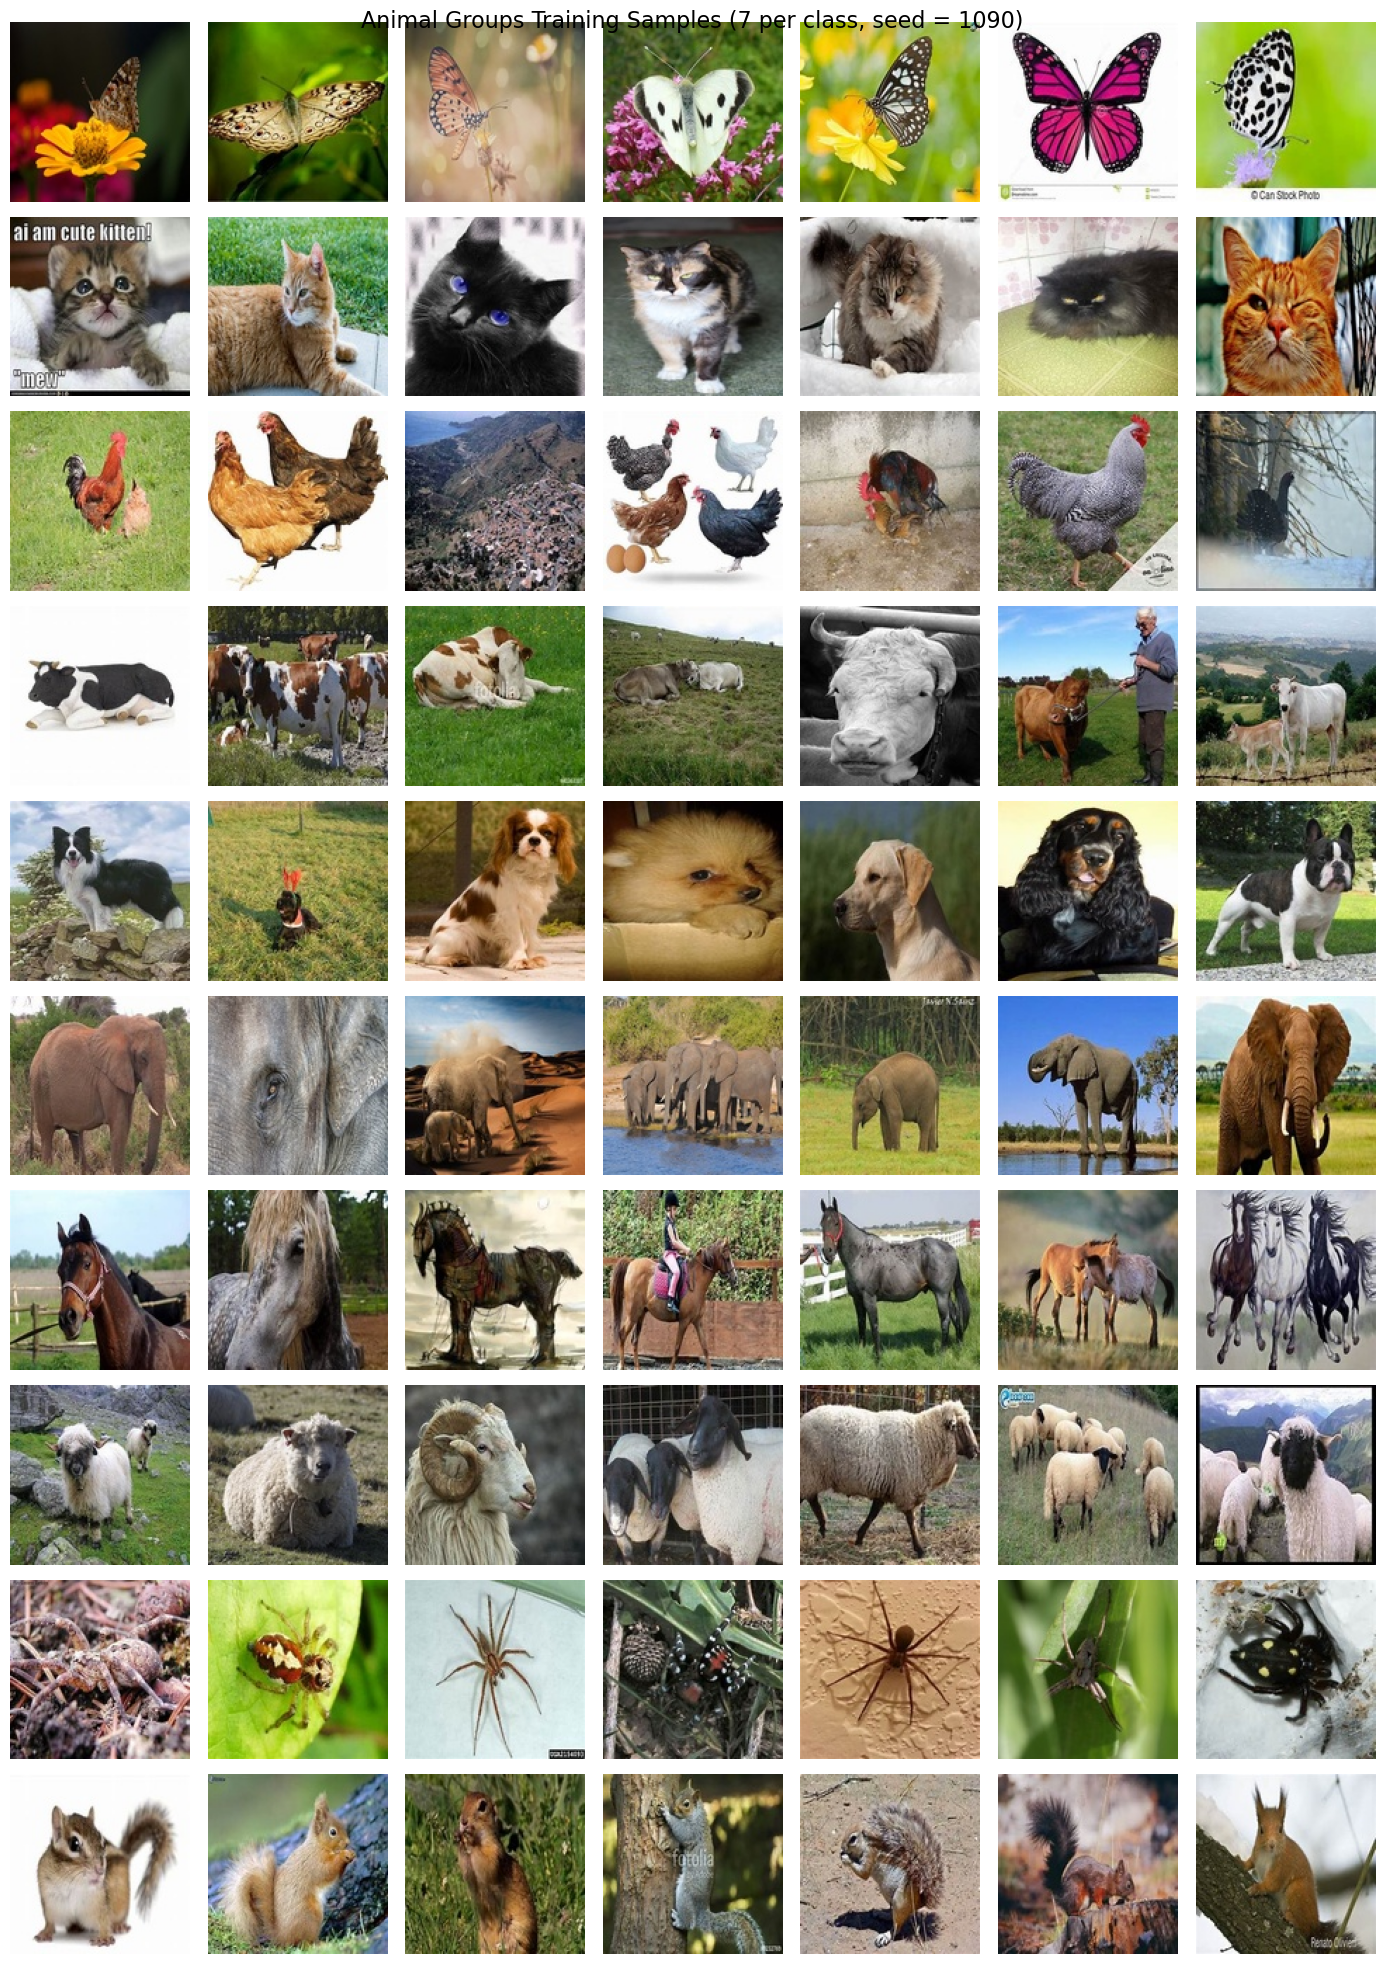

Number of training images: 24179
Number of validation images: 1000
Number of test images: 1000

Number of training images per class:
butterfly: 1912
cat: 1468
chicken: 2898
cow: 1666
dog: 4663
elephant: 1246
horse: 2423
sheep: 1620
spider: 4621
squirrel: 1662


In [ ]:
seed = 1090
rng = np.random.default_rng(seed)

animal_root = DATA_ROOT / 'animal_groups'
train_dir = animal_root / 'train'
val_dir = animal_root / 'val'
test_dir = animal_root / 'test'

class_names = sorted([path.name for path in train_dir.iterdir() if path.is_dir()])
train_class_paths = {class_name: sorted((train_dir / class_name).glob('*')) for class_name in class_names}

fig, axes = plt.subplots(len(class_names), 7, figsize=(14, 20))

for row_idx, class_name in enumerate(class_names):
    sampled_paths = rng.choice(train_class_paths[class_name], size=7, replace=False)
    for col_idx, img_path in enumerate(sampled_paths):
        with Image.open(img_path) as img:
            axes[row_idx, col_idx].imshow(img.convert('RGB'))
        axes[row_idx, col_idx].axis('off')
    axes[row_idx, 0].set_ylabel(class_name, rotation=0, labelpad=50, va='center', fontsize=11)

plt.suptitle('Animal Groups Training Samples (7 per class, seed = 1090)', fontsize=16)
plt.tight_layout()
plt.show()

train_count = sum(len(list((train_dir / class_name).glob('*'))) for class_name in class_names)
val_count = sum(len(list((val_dir / class_name).glob('*'))) for class_name in class_names)
test_count = sum(len(list((test_dir / class_name).glob('*'))) for class_name in class_names)

print(f"Number of training images: {train_count}")
print(f"Number of validation images: {val_count}")
print(f"Number of test images: {test_count}")
print()
print('Number of training images per class:')
for class_name in class_names:
    print(f"{class_name}: {len(train_class_paths[class_name])}")

## 3. Training Setup

### Device Selection, Data Augmentation, and Helper Functions

We set up the compute device (MPS / CUDA / CPU), define image transforms, and create reusable `train_epoch` and `validate` functions.

**Training transforms** include random cropping, horizontal flipping, rotation, and color jitter to reduce overfitting. **Validation/test transforms** only resize and center-crop so that evaluation is deterministic. All images are normalized to the ImageNet mean and standard deviation.

Images are resized to **128×128** for the scratch CNN (smaller input keeps training fast) and later to **224×224** for the ResNet-50 models.

In [ ]:

torch.manual_seed(1090)
np.random.seed(1090)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using Device: {device}\n")



def plot_training_history(train_losses, val_losses, train_accs, val_accs, title = ''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (11, 4))

    ax1.plot(train_losses, label = 'Train Loss', linewidth = 2)
    ax1.plot(val_losses, label = 'Validation Loss', linewidth = 2)
    ax1.set_xlabel('Epoch', fontsize = 12)
    ax1.set_ylabel('Loss', fontsize = 12)
    ax1.set_title('Training and Validation Loss' + (f' - {title}' if title else ''), fontsize = 14)
    ax1.legend()
    ax1.grid(True, alpha = 0.3)

    ax2.plot(train_accs, label = 'Train Accuracy', linewidth = 2)
    ax2.plot(val_accs, label = 'Validation Accuracy', linewidth = 2)
    ax2.set_xlabel('Epoch', fontsize = 12)
    ax2.set_ylabel('Accuracy (%)', fontsize = 12)
    ax2.set_title('Training and Validation Accuracy' + (f' - {title}' if title else ''), fontsize = 14)
    ax2.legend()
    ax2.grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.show()

train_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                       std = [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                       std = [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'train', transform = train_transform)
val_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'val', transform = val_test_transform)
test_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'test', transform = val_test_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

Using Device: cpu



## 4. Model 1 — CNN from Scratch

### Architecture

The custom CNN (`AnimalCNN`) consists of four convolutional blocks, each with a `Conv2d → BatchNorm → ReLU → MaxPool` pattern, progressively increasing the channel depth from 32 to 256. The feature maps are then flattened and passed through a two-layer fully connected classifier with 50% dropout for regularization.

This gives us a relatively lightweight model that must learn all visual features entirely from our training data.

In [ ]:
class AnimalCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = AnimalCNN(num_classes=10).to(device)
print(cnn_model)
print(f"Total Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")


AnimalCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

### Training the Scratch CNN

We train for **10 epochs** using the Adam optimizer with a learning rate of `0.001` and cross-entropy loss. The best model (by validation accuracy) is checkpointed to disk so we can reload it later without re-training. Training history (losses and accuracies) is also saved to an `.npz` file.

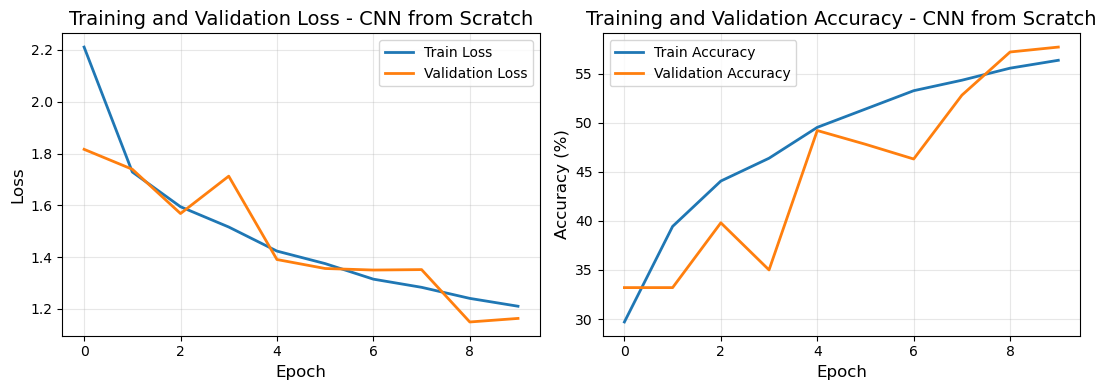

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_checkpoint_path = Path('best_cnn_scratch.pth')
cnn_history_path = Path('cnn_scratch_history.npz')

if cnn_checkpoint_path.exists() and cnn_history_path.exists():
    cnn_model.load_state_dict(torch.load(cnn_checkpoint_path, map_location=device))
    history = np.load(cnn_history_path)
    train_losses = history['train_losses'].tolist()
    val_losses = history['val_losses'].tolist()
    train_accs = history['train_accs'].tolist()
    val_accs = history['val_accs'].tolist()
else:
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(10):
        train_loss, train_acc = train_epoch(cnn_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(cnn_model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(cnn_model.state_dict(), cnn_checkpoint_path)

        print(
            f"Epoch {epoch + 1}/10 | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

    np.savez(
        cnn_history_path,
        train_losses=np.array(train_losses),
        val_losses=np.array(val_losses),
        train_accs=np.array(train_accs),
        val_accs=np.array(val_accs)
    )

plot_training_history(train_losses, val_losses, train_accs, val_accs, title='CNN from Scratch')


### Scratch CNN — Final Evaluation

We reload the best checkpoint and evaluate on the train, validation, and test sets. Because this model had to learn every feature from scratch on a relatively small dataset, we expect moderate accuracy with a noticeable gap between training and test performance.

In [ ]:
cnn_model.load_state_dict(torch.load(cnn_checkpoint_path, map_location=device))

_, cnn_train_acc = validate(cnn_model, train_loader, criterion, device)
_, cnn_val_acc = validate(cnn_model, val_loader, criterion, device)
_, cnn_test_acc = validate(cnn_model, test_loader, criterion, device)

print(f"Final training accuracy: {cnn_train_acc:.2f}%")
print(f"Best validation accuracy: {cnn_val_acc:.2f}%")
print(f"Test accuracy: {cnn_test_acc:.2f}%")

Final training accuracy: 67.75%
Best validation accuracy: 57.70%
Test accuracy: 58.00%


## 5. Transfer Learning with ResNet-50

### Data Preparation for ResNet-50

ResNet-50 was pre-trained on ImageNet at **224×224** resolution, so we rebuild the data loaders with `Resize(256) → CenterCrop(224)` and the standard ImageNet normalization. Using the same preprocessing the model was trained with is critical for transfer learning to work well.

In [ ]:
resnet_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'train', transform=resnet_train_transform)
val_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'val', transform=resnet_val_test_transform)
test_dataset = datasets.ImageFolder(DATA_ROOT / 'animal_groups' / 'test', transform=resnet_val_test_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model 2 — Frozen ResNet-50 (Feature Extraction)

We load a ResNet-50 pre-trained on ImageNet and **freeze all convolutional layers** so their weights are not updated during training. The only trainable component is a new `Linear(2048, 10)` classification head that replaces the original 1000-class output layer.

This approach treats the pre-trained network purely as a fixed feature extractor. It trains extremely fast because gradients only flow through the final linear layer.

In [ ]:
frozen_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in frozen_model.parameters():
    param.requires_grad = False

num_features = frozen_model.fc.in_features
frozen_model.fc = nn.Linear(num_features, 10)
frozen_model = frozen_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(frozen_model.fc.parameters(), lr=0.001)

print(frozen_model.fc)
print(f"Trainable Parameters: {sum(p.numel() for p in frozen_model.parameters() if p.requires_grad):,}")

Linear(in_features=2048, out_features=10, bias=True)
Trainable Parameters: 20,490


### Training the Frozen ResNet-50

We train for only **5 epochs** since only the classification head is being learned — convergence is typically very fast with frozen features. The same checkpointing strategy is used.

In [ ]:
frozen_checkpoint_path = Path('best_resnet50_frozen.pth')
frozen_history_path = Path('resnet50_frozen_history.npz')

if frozen_checkpoint_path.exists() and frozen_history_path.exists():
    frozen_model.load_state_dict(torch.load(frozen_checkpoint_path, map_location=device))
    history = np.load(frozen_history_path)
    frozen_train_losses = history['train_losses'].tolist()
    frozen_val_losses = history['val_losses'].tolist()
    frozen_train_accs = history['train_accs'].tolist()
    frozen_val_accs = history['val_accs'].tolist()
else:
    frozen_train_losses, frozen_val_losses = [], []
    frozen_train_accs, frozen_val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(5):
        train_loss, train_acc = train_epoch(frozen_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(frozen_model, val_loader, criterion, device)

        frozen_train_losses.append(train_loss)
        frozen_val_losses.append(val_loss)
        frozen_train_accs.append(train_acc)
        frozen_val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(frozen_model.state_dict(), frozen_checkpoint_path)

        print(
            f"Epoch {epoch + 1}/5 | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

    np.savez(
        frozen_history_path,
        train_losses=np.array(frozen_train_losses),
        val_losses=np.array(frozen_val_losses),
        train_accs=np.array(frozen_train_accs),
        val_accs=np.array(frozen_val_accs)
    )

### Frozen ResNet-50 — Training Curves

The loss and accuracy curves below show how quickly the frozen model converges. Because the convolutional features are already well-trained from ImageNet, the model reaches strong validation accuracy within just a few epochs.

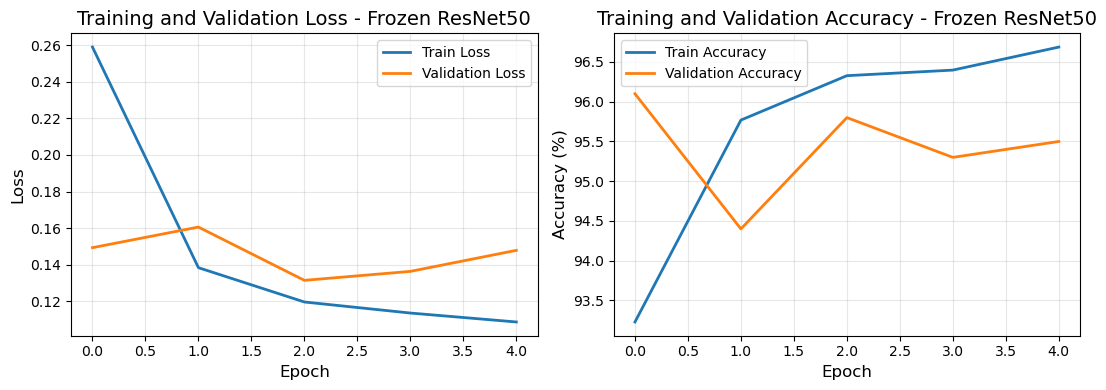

In [ ]:
plot_training_history(
    frozen_train_losses,
    frozen_val_losses,
    frozen_train_accs,
    frozen_val_accs,
    title='Frozen ResNet50'
)

### Frozen ResNet-50 — Final Evaluation

We reload the best frozen checkpoint and evaluate across all splits. Even with all convolutional layers frozen, transfer learning should significantly outperform the scratch CNN because the pre-trained features generalize well to similar visual tasks.

In [ ]:
frozen_model.load_state_dict(torch.load(frozen_checkpoint_path, map_location=device))

_, frozen_train_acc = validate(frozen_model, train_loader, criterion, device)
_, frozen_val_acc = validate(frozen_model, val_loader, criterion, device)
_, frozen_test_acc = validate(frozen_model, test_loader, criterion, device)

print(f"Final training accuracy: {frozen_train_acc:.2f}%")
print(f"Best validation accuracy: {frozen_val_acc:.2f}%")
print(f"Test accuracy: {frozen_test_acc:.2f}%")

Final training accuracy: 96.76%
Best validation accuracy: 96.10%
Test accuracy: 94.00%


### Model 3 — Fine-Tuned ResNet-50

For fine-tuning, we again start from the ImageNet-pre-trained ResNet-50 but this time **unfreeze the last convolutional block** (`layer4[2]`) in addition to the classification head. This lets the network adapt its highest-level features to our specific dataset while keeping the earlier, more general feature layers frozen.

We use a **differential learning rate** strategy: the unfrozen convolutional block is trained at `lr=0.0001` (10× smaller) to avoid destroying the pre-trained features, while the new classification head trains at `lr=0.001`.

In [ ]:
finetuned_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in finetuned_model.parameters():
    param.requires_grad = False

num_features = finetuned_model.fc.in_features
finetuned_model.fc = nn.Linear(num_features, 10)

for param in finetuned_model.layer4[2].parameters():
    param.requires_grad = True
for param in finetuned_model.fc.parameters():
    param.requires_grad = True

finetuned_model = finetuned_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': finetuned_model.layer4[2].parameters(), 'lr': 0.0001},
    {'params': finetuned_model.fc.parameters(), 'lr': 0.001}
])

print(finetuned_model.fc)
print(f"Trainable Parameters: {sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad):,}")

Linear(in_features=2048, out_features=10, bias=True)
Trainable Parameters: 4,483,082


### Training the Fine-Tuned ResNet-50

We train for **10 epochs** with the differential learning rates defined above. The best model by validation accuracy is checkpointed.

In [ ]:
finetuned_checkpoint_path = Path('best_resnet50_finetuned.pth')
finetuned_history_path = Path('resnet50_finetuned_history.npz')

if finetuned_checkpoint_path.exists() and finetuned_history_path.exists():
    finetuned_model.load_state_dict(torch.load(finetuned_checkpoint_path, map_location=device))
    history = np.load(finetuned_history_path)
    finetuned_train_losses = history['train_losses'].tolist()
    finetuned_val_losses = history['val_losses'].tolist()
    finetuned_train_accs = history['train_accs'].tolist()
    finetuned_val_accs = history['val_accs'].tolist()
else:
    finetuned_train_losses, finetuned_val_losses = [], []
    finetuned_train_accs, finetuned_val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(10):
        train_loss, train_acc = train_epoch(finetuned_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(finetuned_model, val_loader, criterion, device)

        finetuned_train_losses.append(train_loss)
        finetuned_val_losses.append(val_loss)
        finetuned_train_accs.append(train_acc)
        finetuned_val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(finetuned_model.state_dict(), finetuned_checkpoint_path)

        print(
            f"Epoch {epoch + 1}/10 | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

    np.savez(
        finetuned_history_path,
        train_losses=np.array(finetuned_train_losses),
        val_losses=np.array(finetuned_val_losses),
        train_accs=np.array(finetuned_train_accs),
        val_accs=np.array(finetuned_val_accs)
    )

### Fine-Tuned ResNet-50 — Training Curves

The training curves below should show the fine-tuned model reaching the highest overall accuracy of all three approaches, with the gap between train and validation accuracy remaining small thanks to the regularizing effect of the frozen early layers.

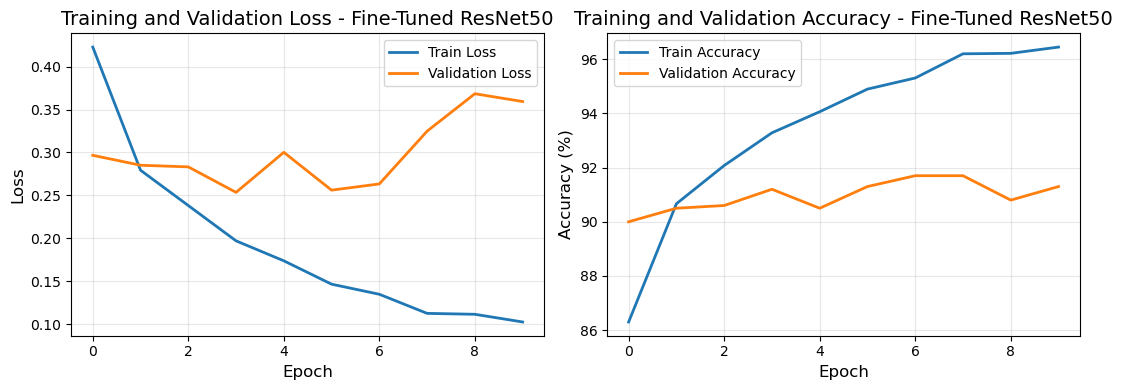

In [ ]:
plot_training_history(
    finetuned_train_losses,
    finetuned_val_losses,
    finetuned_train_accs,
    finetuned_val_accs,
    title='Fine-Tuned ResNet50'
)

### Fine-Tuned ResNet-50 — Final Evaluation

We reload the best fine-tuned checkpoint and evaluate on all splits. This model is expected to achieve the best test accuracy since it combines the power of pre-trained features with task-specific adaptation.

In [ ]:
finetuned_model.load_state_dict(torch.load(finetuned_checkpoint_path, map_location=device))

_, finetuned_train_acc = validate(finetuned_model, train_loader, criterion, device)
_, finetuned_val_acc = validate(finetuned_model, val_loader, criterion, device)
_, finetuned_test_acc = validate(finetuned_model, test_loader, criterion, device)

print(f"Final training accuracy: {finetuned_train_acc:.2f}%")
print(f"Best validation accuracy: {finetuned_val_acc:.2f}%")
print(f"Test accuracy: {finetuned_test_acc:.2f}%")

Final training accuracy: 94.16%
Best validation accuracy: 90.10%
Test accuracy: 89.60%


## 6. Model Comparison

The table below summarizes the train, validation, and test accuracy for all three models side by side. Key takeaways:

- **Transfer learning (even frozen)** dramatically outperforms a CNN trained from scratch, demonstrating the value of pre-trained features learned on a large-scale dataset like ImageNet.
- **Fine-tuning** provides an additional accuracy boost over the frozen approach by allowing the network to adapt its high-level features to the target domain.
- The scratch CNN is the most prone to overfitting, as it must learn all representations from a limited amount of data.

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'CNN from Scratch',
        'Frozen Transfer Learning',
        'Fine-Tuned Transfer Learning'
    ],
    'Train Accuracy': [cnn_train_acc, frozen_train_acc, finetuned_train_acc],
    'Validation Accuracy': [cnn_val_acc, frozen_val_acc, finetuned_val_acc],
    'Test Accuracy': [cnn_test_acc, frozen_test_acc, finetuned_test_acc]
})

comparison_df = comparison_df.set_index('Model')
display(comparison_df.style.format('{:.2f}'))

,Train Accuracy,Validation Accuracy,Test Accuracy
Model,,,
CNN from Scratch,67.75,57.70,58.00
Frozen Transfer Learning,96.76,96.10,94.00
Fine-Tuned Transfer Learning,94.16,90.10,89.60
